In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras
from scipy.interpolate import CubicSpline
from tensorflow.keras import layers, regularizers, callbacks, models
import joblib
from tensorflow.keras.layers import Conv1D, Input, Dense, Lambda, Add, MultiHeadAttention, LayerNormalization, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Model
import json, joblib, os
from sklearn.ensemble import RandomForestRegressor
import time
import subprocess


# List input data files
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Set random seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configure matplotlib style
plt.style.use('seaborn')
%matplotlib inline

2026-02-12 12:45:50.938655: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770900351.183850      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770900351.249244      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


/kaggle/input/cryptocurrency/bitcoin_historical_yahoo.csv
/kaggle/input/cryptocurrency/solana_historical_yahoo.csv
/kaggle/input/cryptocurrency/ethereum_historical_yahoo.csv


/tmp/ipykernel_38/1791569138.py:33: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


# Data loading and Preprocessing

In [2]:
# Define dataset paths (replace with actual paths as needed)
datasets = [
    '/kaggle/input/cryptocurrency/solana_historical_yahoo.csv',
    '/kaggle/input/cryptocurrency/ethereum_historical_yahoo.csv',  # Example second dataset
    '/kaggle/input/cryptocurrency/bitcoin_historical_yahoo.csv'   # Example third dataset
]

# Dictionary to store processed data
data_dict = {}

# Process each dataset
for dataset_path in datasets:
    # Read dataset
    df = pd.read_csv(dataset_path)
    
    # Convert date column to datetime and sort
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.set_index('date')
    
    # Drop unnecessary columns
    df = df.drop(['price'], axis=1, errors='ignore')
    
    # Remove missing values
    df = df.dropna()

    print(df.head())
    
    # Define feature columns
    feature_cols = ['open', 'high', 'low', 'close', 'volume']
    data_array = df[feature_cols].values  # Convert to numpy array (time × features)
    
    # Split into train/test (80% / 20%)
    train_size = int(len(data_array) * 0.8)
    train_data = data_array[:train_size]
    test_data = data_array[train_size:]
    
    print(f"\nDataset: {dataset_path}")
    print(f"Training data: {len(train_data)} samples")
    print(f"Test data: {len(test_data)} samples")
    
    # Normalize using MinMaxScaler
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(train_data)
    scaled_test = scaler.transform(test_data)
    
    # Save scaler for later use
    dataset_name = os.path.basename(dataset_path).split('_')[0] 
    joblib.dump(scaler, f'/kaggle/working/scaler_{dataset_name}.joblib')
    
    # Store processed data
    data_dict[dataset_name] = {
        'train_data': scaled_train,
        'test_data': scaled_test,
        'original_data': data_array,
        'scaler': scaler,
        'df': df,
        'train_size': train_size
    }



                open      high       low     close    volume
date                                                        
2020-04-10  0.832005  1.313487  0.694187  0.951054  87364276
2020-04-11  0.951054  1.049073  0.765020  0.776819  43862444
2020-04-12  0.785448  0.956670  0.762426  0.882507  38736897
2020-04-13  0.890760  0.891603  0.773976  0.777832  18211285
2020-04-14  0.777832  0.796472  0.628169  0.661925  16747614

Dataset: /kaggle/input/cryptocurrency/solana_historical_yahoo.csv
Training data: 1479 samples
Test data: 370 samples
                  open        high         low       close      volume
date                                                                  
2017-11-09  308.644989  329.451996  307.056000  320.884003   893249984
2017-11-10  320.670990  324.717987  294.541992  299.252991   885985984
2017-11-11  298.585999  319.453003  298.191986  314.681000   842300992
2017-11-12  314.690002  319.153015  298.513000  307.907990  1613479936
2017-11-13  307.024994  328.4

## Visualização dos dados normalizados

/tmp/ipykernel_38/3817311060.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figura salva em: /kaggle/working/figures/datasets_normalizados_2x1.png


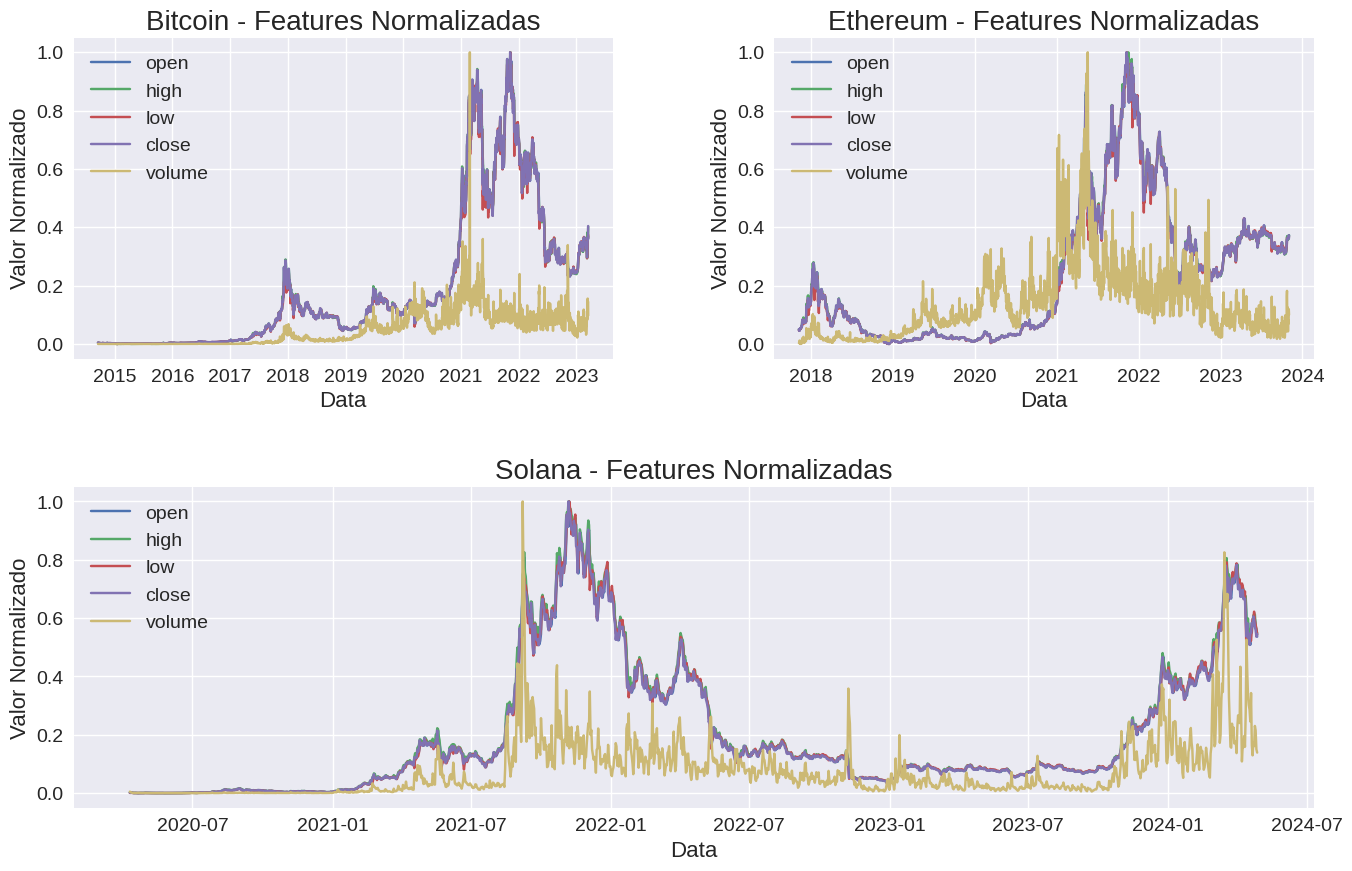

In [3]:
# Diretório para salvar figuras
output_dir = '/kaggle/working/figures'
os.makedirs(output_dir, exist_ok=True)  # cria o diretório se não existir

# Ordenar datasets para plot: 2 primeiros na linha de cima, 1 na de baixo
plot_order = ['bitcoin', 'ethereum', 'solana']

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1], hspace=0.4, wspace=0.3)

# Fonte para títulos, labels e ticks
title_fontsize = 20
label_fontsize = 16
tick_fontsize = 14
legend_fontsize = 14

# Gráfico 1: Bitcoin
ax1 = fig.add_subplot(gs[0, 0])
df_scaled = pd.DataFrame(data_dict['bitcoin']['train_data'],
                         columns=['open','high','low','close','volume'],
                         index=data_dict['bitcoin']['df'].index[:data_dict['bitcoin']['train_size']])
for col in df_scaled.columns:
    ax1.plot(df_scaled[col], label=col)
ax1.set_title('Bitcoin - Features Normalizadas', fontsize=title_fontsize)
ax1.set_xlabel('Data', fontsize=label_fontsize)
ax1.set_ylabel('Valor Normalizado', fontsize=label_fontsize)
ax1.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax1.legend(loc='upper left', fontsize=legend_fontsize)  # legenda no canto superior esquerdo

# Gráfico 2: Ethereum
ax2 = fig.add_subplot(gs[0, 1])
df_scaled = pd.DataFrame(data_dict['ethereum']['train_data'],
                         columns=['open','high','low','close','volume'],
                         index=data_dict['ethereum']['df'].index[:data_dict['ethereum']['train_size']])
for col in df_scaled.columns:
    ax2.plot(df_scaled[col], label=col)
ax2.set_title('Ethereum - Features Normalizadas', fontsize=title_fontsize)
ax2.set_xlabel('Data', fontsize=label_fontsize)
ax2.set_ylabel('Valor Normalizado', fontsize=label_fontsize)
ax2.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax2.legend(loc='upper left', fontsize=legend_fontsize)  # canto superior esquerdo

# Gráfico 3: Solana (linha de baixo, ocupando as duas colunas)
ax3 = fig.add_subplot(gs[1, :])
df_scaled = pd.DataFrame(data_dict['solana']['train_data'],
                         columns=['open','high','low','close','volume'],
                         index=data_dict['solana']['df'].index[:data_dict['solana']['train_size']])
for col in df_scaled.columns:
    ax3.plot(df_scaled[col], label=col)
ax3.set_title('Solana - Features Normalizadas', fontsize=title_fontsize)
ax3.set_xlabel('Data', fontsize=label_fontsize)
ax3.set_ylabel('Valor Normalizado', fontsize=label_fontsize)
ax3.tick_params(axis='both', which='major', labelsize=tick_fontsize)
ax3.legend(loc='upper left', fontsize=legend_fontsize)  # canto superior esquerdo

plt.tight_layout()

# Salvar a figura
save_path = os.path.join(output_dir, 'datasets_normalizados_2x1.png')
plt.savefig(save_path, dpi=200, bbox_inches='tight')
print(f'Figura salva em: {save_path}')

plt.show()


# Sequence Creation and Data Augmentation

In [4]:

# Function to create supervised sequences
def create_sequences(data, window_size=60, target_col=feature_cols.index('close')):
    """
    Creates sliding windows: X = windows of size window_size with all features
    y = value of the target_col in the next step.
    data: numpy array (N x num_features) already scaled
    """
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i - window_size:i, :])
        y.append(data[i, target_col])
    return np.array(X), np.array(y)

# Create sequences for each dataset
window_size = 60
sequences_dict = {}
for name, data in data_dict.items():
    X_train, y_train = create_sequences(data['train_data'], window_size)
    X_test, y_test = create_sequences(data['test_data'], window_size)
    sequences_dict[name] = {
        'X_train': X_train,
        'y_train': y_train,
        'X_test': X_test,
        'y_test': y_test
    }
    print(f"\nDataset: {name}")
    print(f"Training shapes - X: {X_train.shape}, y: {y_train.shape}")
    print(f"Test shapes - X: {X_test.shape}, y: {y_test.shape}")

# Data augmentation functions
def jitter(X, sigma=0.005):
    noise = np.random.normal(0.0, sigma, size=X.shape)
    return X + noise

def drift(X, max_drift=0.03, n_drift_points=3):
    X_aug = np.empty_like(X)
    n_samples, T, n_features = X.shape
    for i in range(n_samples):
        pts = np.linspace(0, T - 1, n_drift_points + 2)
        vals = np.random.uniform(-max_drift, max_drift, size=n_drift_points + 2)
        cs = CubicSpline(pts, vals)
        curve = cs(np.arange(T))
        X_aug[i] = X[i] * (1 + curve[:, None])
    return X_aug

for name in sequences_dict:
    X_train = sequences_dict[name]['X_train']
    y_train = sequences_dict[name]['y_train']
    
    X_jit = jitter(X_train, sigma=0.005)
    X_drift = drift(X_train, max_drift=0.03, n_drift_points=3)
    
    X_train_ext = np.vstack([X_train, X_jit, X_drift])
    y_train_ext = np.concatenate([y_train, y_train, y_train])
    
    idx = np.random.permutation(len(X_train_ext))
    X_train_ext, y_train_ext = X_train_ext[idx], y_train_ext[idx]
    
    sequences_dict[name]['X_train_ext'] = X_train_ext
    sequences_dict[name]['y_train_ext'] = y_train_ext
    
    print(f"Extended training size for {name}: {X_train_ext.shape}")


Dataset: solana
Training shapes - X: (1419, 60, 5), y: (1419,)
Test shapes - X: (310, 60, 5), y: (310,)

Dataset: ethereum
Training shapes - X: (2125, 60, 5), y: (2125,)
Test shapes - X: (487, 60, 5), y: (487,)

Dataset: bitcoin
Training shapes - X: (3044, 60, 5), y: (3044,)
Test shapes - X: (717, 60, 5), y: (717,)
Extended training size for solana: (4257, 60, 5)
Extended training size for ethereum: (6375, 60, 5)
Extended training size for bitcoin: (9132, 60, 5)


# Model Definitions

In [5]:

# Function to compile model
def compile_model(model, lr=1e-3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae', tf.keras.metrics.RootMeanSquaredError()]
    )
    return model

# LSTM Model
def build_lstm(input_shape):
    model = keras.Sequential([
        layers.LSTM(100, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.3),
        layers.LSTM(100, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(1)
    ])
    return compile_model(model)

# GRU Model
def build_gru(input_shape):
    model = keras.Sequential([
        layers.GRU(100, return_sequences=True, input_shape=input_shape),
        layers.Dropout(0.3),
        layers.GRU(100, return_sequences=False),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
        layers.Dense(1)
    ])
    return compile_model(model)

# TCN Model
def build_tcn(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=1, padding='causal', activation='relu')(inputs)
    
    def tcn_block(x, dilation_rate, filters=64, kernel_size=3):
        conv = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate, activation='relu')(x)
        conv = layers.Dropout(0.2)(conv)
        conv = layers.Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate, activation='relu')(conv)
        if x.shape[-1] != filters:
            x = Conv1D(filters, 1, padding='same')(x)
        return Add()([x, conv])
    
    for dilation in [1, 2, 4, 8, 16]:
        x = tcn_block(x, dilation)
    
    x = layers.Dense(32, activation='relu')(x[:, -1, :])
    outputs = layers.Dense(1)(x)
    model = Model(inputs=inputs, outputs=outputs)
    return compile_model(model)

# Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        out1 = self.layernorm1(inputs + self.dropout1(attn_output, training=training))
        ffn_output = self.ffn(out1)
        return self.layernorm2(out1 + self.dropout2(ffn_output, training=training))

# Positional Encoding
class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, d_model):
        super().__init__()
        pos = np.arange(sequence_length)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        angle_rads = pos * angle_rates
        sines = np.sin(angle_rads[:, 0::2])
        cosines = np.cos(angle_rads[:, 1::2])
        self.pos_encoding = tf.constant(np.concatenate([sines, cosines], axis=-1), dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[tf.newaxis, :tf.shape(inputs)[1], :]

# Transformer Model
def build_transformer(input_shape, heads=4, ff_dim=128):
    inputs = layers.Input(shape=input_shape)
    x = layers.Dense(64)(inputs)
    x = PositionalEncoding(sequence_length=input_shape[0], d_model=64)(x)
    x = TransformerBlock(embed_dim=64, num_heads=heads, ff_dim=ff_dim)(x, training=True)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    return compile_model(model)



# Initial Settings

In [6]:
# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6
)

# Model builders
model_builders = {
    'LSTM': build_lstm,
    'GRU': build_gru,
    'TCN': build_tcn,
    'Transformer': build_transformer
}

# -- Metadata and paths --
TIMESTAMP = time.strftime("%Y%m%d_%H%M%S")
BASE_OUT = '/kaggle/working/artifacts'
MODEL_DIR = os.path.join(BASE_OUT, 'models')
SCALER_DIR = os.path.join(BASE_OUT, 'scalers')
PLOTS_DIR = os.path.join(BASE_OUT, 'plots')
HISTORY_DIR = os.path.join(BASE_OUT, 'history')
PRED_DIR = os.path.join(BASE_OUT, 'predictions')
METRICS_DIR = os.path.join(BASE_OUT, 'metrics')
CONFIG_DIR = os.path.join(BASE_OUT, 'config')
for p in [BASE_OUT, MODEL_DIR, SCALER_DIR, PLOTS_DIR, HISTORY_DIR, PRED_DIR, METRICS_DIR, CONFIG_DIR]:
    os.makedirs(p, exist_ok=True)

# -- Config (útil para deploy/inferência posterior) --
#config = {
# "window_size": int(window_size),
# "feature_cols": feature_cols,
# "target_col": "close",
# "target_index": int(feature_cols.index('close')),
# "seed": int(SEED)
#}
#config_path = os.path.join(CONFIG_DIR, f"config_{TIMESTAMP}.json")
#with open(config_path, 'w') as f:
#    json.dump(config, f)
#print("Saved config:", config_path)

# CORREÇÃO: Função inverse_transform_predictions única e robusta
def inverse_transform_predictions(scaler_obj, predictions, n_features, close_index=3):  # close é o índice 3 em ['open', 'high', 'low', 'close', 'volume']
    """
    Inverse transform predictions from scaled to original values.
    """
    preds = np.array(predictions).reshape(-1, 1)
    
    # Create dummy array with same number of features as original data
    dummy = np.zeros((len(preds), n_features), dtype=float)
    dummy[:, close_index] = preds[:, 0]  # assuming target is 'close' at index 3
    
    try:
        inv = scaler_obj.inverse_transform(dummy)
        return inv[:, close_index]
    except Exception as e:
        print(f"Error in inverse transform: {e}")
        # Fallback: try direct inverse transform if scaler was fitted on 1D data
        try:
            return scaler_obj.inverse_transform(preds).ravel()
        except:
            return preds.ravel()  # return as is if all fails


# -- Ensure a clean session --
keras.backend.clear_session()

# Global container of results (by dataset) --
all_results = {} # { dataset_name: { model_name: { ... } } }

NameError: name 'build_random_forest' is not defined

# Main Training Loop


In [ ]:
# Training / Assessment and Rescue
for dataset_name in sequences_dict:
    print(f"\n==== Processing dataset: {dataset_name} ====")
    results = {}
    input_shape = (sequences_dict[dataset_name]['X_train'].shape[1], sequences_dict[dataset_name]['X_train'].shape[2])
   
    # save standardized climber
    scaler = data_dict[dataset_name]['scaler']
    scaler_path = os.path.join(SCALER_DIR, f"scaler_{dataset_name}_{TIMESTAMP}.joblib")
    joblib.dump(scaler, scaler_path)
    print("Saved scaler:", scaler_path)
   
    # informs about shapes
    print("Input shape (timesteps, features):", input_shape)
       
    for name, builder in model_builders.items():
        print(f"\n>> Training model: {name} on dataset: {dataset_name}")
        model = builder(input_shape)
        history = None
        rf_path = None
        ckpt_path = None
       
        # --- Training ---
        if name.lower().startswith('randomforest') or name == 'RandomForest':
            # RandomForest expects 2D arrays
            X_train_flat = sequences_dict[dataset_name]['X_train'].reshape(sequences_dict[dataset_name]['X_train'].shape[0], -1)
            X_test_flat = sequences_dict[dataset_name]['X_test'].reshape(sequences_dict[dataset_name]['X_test'].shape[0], -1)
            model.fit(X_train_flat, sequences_dict[dataset_name]['y_train'])
            # save RF
            rf_path = os.path.join(MODEL_DIR, f"rf_{dataset_name}_{name}_{TIMESTAMP}.joblib")
            joblib.dump(model, rf_path)
            print("Saved RandomForest model to:", rf_path)
            preds_scaled_test = model.predict(X_test_flat)
            preds_scaled_train = model.predict(X_train_flat)
        else:
            # define checkpoint path consistente
            ckpt_path = os.path.join(MODEL_DIR, f"best_{dataset_name}_{name}_{TIMESTAMP}.h5")
            # fit with predefined callbacks (early_stopping, reduce_lr)
            history_obj = model.fit(
                sequences_dict[dataset_name]['X_train_ext'],
                sequences_dict[dataset_name]['y_train_ext'],
                epochs=100,
                batch_size=32,
                validation_split=0.1,
                callbacks=[
                    early_stopping,
                    reduce_lr,
                    callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True)
                ],
                verbose=1
            )
            history = history_obj.history
            # Explicitly load the best saved model (ensures consistency)
            try:
                model = keras.models.load_model(ckpt_path)
                print("Loaded best checkpoint from:", ckpt_path)
            except Exception as e:
                print("Warning: could not load checkpoint, using in-memory model. Error:", e)
            preds_scaled_test = model.predict(sequences_dict[dataset_name]['X_test']).ravel()
            preds_scaled_train = model.predict(sequences_dict[dataset_name]['X_train']).ravel()
       
        # Convert predictions and y_true to original scale
        n_features = data_dict[dataset_name]['original_data'].shape[1]
        try:
            test_pred = inverse_transform_predictions(data_dict[dataset_name]['scaler'], preds_scaled_test, n_features)
            train_pred = inverse_transform_predictions(data_dict[dataset_name]['scaler'], preds_scaled_train, n_features)
            y_test_actual = inverse_transform_predictions(data_dict[dataset_name]['scaler'], sequences_dict[dataset_name]['y_test'], n_features)
            y_train_actual = inverse_transform_predictions(data_dict[dataset_name]['scaler'], sequences_dict[dataset_name]['y_train'], n_features)
        except Exception as e:
            print("Error during inverse_transform_predictions:", e)
            raise e
       
        # Metrics (in real space)
        mae = mean_absolute_error(y_test_actual, test_pred)
        rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))
        mape = np.mean(np.abs((y_test_actual - test_pred) / (y_test_actual + 1e-9))) * 100
        r2 = r2_score(y_test_actual, test_pred)
        loss_scaled = float(mean_squared_error(sequences_dict[dataset_name]['y_test'], preds_scaled_test)) if preds_scaled_test is not None else None
       
        metrics_dict = {
            "loss_scaled": None if loss_scaled is None else float(loss_scaled),
            "MAE": float(mae),
            "RMSE": float(rmse),
            "MAPE": float(mape),
            "R2": float(r2)
        }
       
        # Save history, metrics, predictions, figures
        #history
        hist_path = os.path.join(HISTORY_DIR, f"history_{dataset_name}_{name}_{TIMESTAMP}.json")
        if history is not None:
            with open(hist_path, 'w') as f:
                json.dump(history, f)
        else:
            hist_path = None
       
        # metrics
        metrics_path = os.path.join(METRICS_DIR, f"metrics_{dataset_name}_{name}_{TIMESTAMP}.json")
        with open(metrics_path, 'w') as f:
            json.dump(metrics_dict, f)
       
        # predictions CSV
        # Calculating dates safely:
        test_start_index_in_df = data_dict[dataset_name]['train_size'] + window_size
        n_test = len(y_test_actual)
        df_dates = data_dict[dataset_name]['df'].index[test_start_index_in_df: test_start_index_in_df + n_test]
        preds_df = pd.DataFrame({
            'date': df_dates,
            'y_true': y_test_actual,
            'y_pred': test_pred
        })
        pred_csv_path = os.path.join(PRED_DIR, f"preds_{dataset_name}_{name}_{TIMESTAMP}.csv")
        preds_df.to_csv(pred_csv_path, index=False)
       
        # plot preds vs actual (test)
        fig_path = os.path.join(PLOTS_DIR, f"pred_{dataset_name}_{name}_{TIMESTAMP}.png")
        plt.figure(figsize=(12,5))
        plt.plot(df_dates, y_test_actual, label='actual_test', alpha=0.7)
        plt.plot(df_dates, test_pred, label='pred_test', linestyle='--')
        if hist_path:
            # Optional: Add loss curve from history.
            pass
        plt.title(f'{name} - {dataset_name}')
        plt.legend()
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.savefig(fig_path, dpi=200)
        plt.close()
       
        # Save final template (if applicable) - for Keras, ckpt_path already contains a .h5 file.
        final_model_path = None
        if rf_path is not None:
            final_model_path = rf_path
        elif ckpt_path is not None and os.path.exists(ckpt_path):
            final_model_path = ckpt_path
        else:
            # alternative: save the model in SavedModel (if the Keras model is in memory)
            try:
                alt_path = os.path.join(MODEL_DIR, f"{dataset_name}_{name}_{TIMESTAMP}_savedmodel")
                model.save(alt_path, save_format='tf')
                final_model_path = alt_path
            except Exception:
                final_model_path = None
       
        # Save everything in results dict
        results[name] = {
            'model_obj': model,
            'model_path': final_model_path,
            'scaler_path': scaler_path,
            'history_path': hist_path,
            'metrics_path': metrics_path,
            'preds_csv': pred_csv_path,
            'plot_path': fig_path,
            'metrics': metrics_dict
        }
        print(f"Saved artifacts for model {name} (dataset {dataset_name}).")

    # ==========================================================
#  PLOT: TRAIN & VAL LOSS (SUBPLOTS) + EARLY STOP MARKERS
# ==========================================================

train_losses = {}
val_losses = {}
early_stops = {}

for model_name, info in results.items():
    if info["history_path"] is None:
        continue  # RandomForest não tem history

    with open(info["history_path"], "r") as f:
        hist = json.load(f)

    # Apenas modelos com history (LSTM, GRU, TCN, Transformer)
    if "loss" in hist:
        train_losses[model_name] = hist["loss"]
    if "val_loss" in hist:
        val_losses[model_name] = hist["val_loss"]

    # EarlyStopping epoch, se existir no JSON
    if "stopped_epoch" in hist:
        early_stops[model_name] = hist["stopped_epoch"]
    else:
        early_stops[model_name] = None


# Se existir ao menos 1 modelo com loss → gerar subplots
if len(train_losses) > 0 and len(val_losses) > 0:

    fig, axs = plt.subplots(1, 2, figsize=(16, 6))

    # -----------------------------------------------------
    # SUBPLOT 1: TRAIN LOSS
    # -----------------------------------------------------
    for model_name, loss_list in train_losses.items():
        axs[0].plot(loss_list, label=model_name)

        # Marca EarlyStopping, se existir
        if early_stops[model_name] is not None:
            axs[0].axvline(
                early_stops[model_name],
                linestyle="--",
                alpha=0.6,
                label=f"{model_name} ES epoch {early_stops[model_name]}"
            )

    axs[0].set_title(f"Training Loss Comparison - {dataset_name}")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Training Loss")
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # -----------------------------------------------------
    # SUBPLOT 2: VALIDATION LOSS
    # -----------------------------------------------------
    for model_name, loss_list in val_losses.items():
        axs[1].plot(loss_list, label=model_name)

        # Marca EarlyStopping, se existir
        if early_stops[model_name] is not None:
            axs[1].axvline(
                early_stops[model_name],
                linestyle="--",
                alpha=0.6,
                label=f"{model_name} ES epoch {early_stops[model_name]}"
            )

    axs[1].set_title(f"Validation Loss Comparison - {dataset_name}")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Validation Loss")
    axs[1].legend()
    axs[1].grid(True, alpha=0.3)

    # -----------------------------------------------------
    # Salvar
    # -----------------------------------------------------
    out_path_subplots = os.path.join(
        PLOTS_DIR,
        f"loss_train_val_subplots_{dataset_name}_{TIMESTAMP}.png"
    )

    plt.tight_layout()
    plt.savefig(out_path_subplots, dpi=200)
    plt.close()
    print("Saved:", out_path_subplots)
   
    # save results by dataset
    all_results[dataset_name] = results

In [ ]:
# Single cell: create 2 plots per dataset (loss and val_loss) comparing all models
import os
import glob
import json
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import re

# --- CONFIG ---
HISTORY_DIR = os.path.join("artifacts", "history")
OUT_PLOTS_DIR = os.path.join("artifacts", "plots", "dataset_comparisons")
OUT_CSV_DIR = os.path.join("artifacts", "plots", "dataset_comparisons_csv")
os.makedirs(OUT_PLOTS_DIR, exist_ok=True)
os.makedirs(OUT_CSV_DIR, exist_ok=True)

# Known model tokens (case-insensitive)
KNOWN_MODELS = ["LSTM", "GRU", "TCN", "TRANSFORMER"]

def detect_model_and_dataset(filename):
    """
    Try to detect model token (one of KNOWN_MODELS) from the basename.
    Returns (dataset_key, model_token).
    dataset_key is the part before the model token (joined by underscores).
    """
    base = os.path.basename(filename).replace(".json", "")
    # remove leading "history_" if present
    base = re.sub(r"^history_", "", base, flags=re.IGNORECASE)
    parts = base.split("_")
    # find index of any known model token (case-insensitive)
    model_idx = None
    model_token = None
    for i, p in enumerate(parts):
        for m in KNOWN_MODELS:
            if p.lower() == m.lower():
                model_idx = i
                model_token = m  # canonical token
                break
        if model_idx is not None:
            break

    # fallback: if no known model token found, assume second-to-last part is model
    if model_idx is None and len(parts) >= 2:
        model_idx = len(parts) - 2
        model_token = parts[model_idx]

    # dataset is everything before model_idx
    if model_idx is not None:
        dataset = "_".join(parts[:model_idx])
    else:
        dataset = "_".join(parts[:-1]) if len(parts) > 1 else parts[0]

    return dataset or "unknown_dataset", str(model_token)

def load_json_safe(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return None

def save_fig(fig, name):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    fname = f"{name}_{ts}.png"
    path = os.path.join(OUT_PLOTS_DIR, fname)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    return path

def save_csv(df, name):
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    fname = f"{name}_{ts}.csv"
    path = os.path.join(OUT_CSV_DIR, fname)
    df.to_csv(path, index=True)
    return path

# gather history files
history_files = sorted(glob.glob(os.path.join(HISTORY_DIR, "history_*.json")))

if not history_files:
    print("No history files found in", HISTORY_DIR)
else:
    print(f"Found {len(history_files)} history files.")
    # group by dataset
    grouped = {}
    for f in history_files:
        dataset, model = detect_model_and_dataset(f)
        hist = load_json_safe(f)
        if hist is None:
            continue
        grouped.setdefault(dataset, {})[model] = hist

    print("Datasets:", list(grouped.keys()))

    # For each dataset create 2 plots: loss comparison and val_loss comparison
    for dataset, models in grouped.items():
        print("\nProcessing dataset:", dataset)
        # Prepare DataFrames for losses and val_losses with columns = models
        loss_df = pd.DataFrame()
        val_loss_df = pd.DataFrame()

        # track max epochs for nice x-axis
        max_epochs_loss = 0
        max_epochs_val = 0

        for model_name, hist in models.items():
            # pick loss arrays if present
            if "loss" in hist:
                s = pd.Series(hist["loss"], name=model_name)
                loss_df = pd.concat([loss_df, s], axis=1)
                max_epochs_loss = max(max_epochs_loss, len(s))
            if "val_loss" in hist:
                s2 = pd.Series(hist["val_loss"], name=model_name)
                val_loss_df = pd.concat([val_loss_df, s2], axis=1)
                max_epochs_val = max(max_epochs_val, len(s2))

        # Make epoch index 1-based
        if not loss_df.empty:
            loss_df.index = loss_df.index + 1
        if not val_loss_df.empty:
            val_loss_df.index = val_loss_df.index + 1

        # Plot LOSS comparison (all models on one plot)
        if not loss_df.empty:
            fig, ax = plt.subplots(figsize=(12,6))
            for col in loss_df.columns:
                ax.plot(loss_df.index, loss_df[col], label=col, linewidth=2)
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Loss")
            ax.set_title(f"{dataset} — Training Loss (all models)")
            ax.set_xlim(1, max(1, max_epochs_loss))
            ax.grid(alpha=0.25)
            ax.legend(loc="best")
            loss_png = save_fig(fig, f"{dataset}_loss_comparison")
            print(" Saved loss plot:", loss_png)
        else:
            print(" No 'loss' data available for dataset", dataset)

        # Plot VAL_LOSS comparison
        if not val_loss_df.empty:
            fig2, ax2 = plt.subplots(figsize=(12,6))
            for col in val_loss_df.columns:
                ax2.plot(val_loss_df.index, val_loss_df[col], label=col, linewidth=2)
            ax2.set_xlabel("Epoch")
            ax2.set_ylabel("Val Loss")
            ax2.set_title(f"{dataset} — Validation Loss (all models)")
            ax2.set_xlim(1, max(1, max_epochs_val))
            ax2.grid(alpha=0.25)
            ax2.legend(loc="best")
            val_png = save_fig(fig2, f"{dataset}_val_loss_comparison")
            print(" Saved val_loss plot:", val_png)
        else:
            print(" No 'val_loss' data available for dataset", dataset)

        # Save combined CSV (loss and val_loss side-by-side)
        if not loss_df.empty or not val_loss_df.empty:
            # rename indices to epoch and combine using outer join on epoch
            loss_df.index.name = "epoch"
            val_loss_df.index.name = "epoch"
            combined = pd.concat(
                [loss_df.add_prefix("loss_"), val_loss_df.add_prefix("val_loss_")],
                axis=1,
                sort=False
            )
            csv_path = save_csv(combined, f"{dataset}_loss_and_val_loss")
            print(" Saved CSV:", csv_path)

    print("\nDone. Plots in:", os.path.abspath(OUT_PLOTS_DIR))
    print("CSVs in:", os.path.abspath(OUT_CSV_DIR))


# Post-processing and aggregation of metrics

In [ ]:
# Post-processing: aggregation of metrics by model (across datasets)
models = sorted(list(next(iter(all_results.values())).keys()))
metrics_list = ["MAE", "RMSE", "MAPE", "R2"]
metrics_storage = {m: {metric: [] for metric in metrics_list} for m in models}
for ds, resdict in all_results.items():
    for mdl, info in resdict.items():
        for metric in metrics_list:
            metrics_storage[mdl][metric].append(info['metrics'][metric])

# create aggregated dataframes
agg_means = {metric: [np.mean(metrics_storage[mdl][metric]) for mdl in models] for metric in metrics_list}
agg_stds = {metric: [np.std(metrics_storage[mdl][metric], ddof=1) if len(metrics_storage[mdl][metric])>1 else 0.0 for mdl in models] for metric in metrics_list}
df_means = pd.DataFrame({m: agg_means[m] for m in metrics_list}, index=models)
df_stds = pd.DataFrame({m: agg_stds[m] for m in metrics_list}, index=models)

# save aggregated dataframes
df_means.to_csv(os.path.join(METRICS_DIR, f"aggregated_means_{TIMESTAMP}.csv"))
df_stds.to_csv(os.path.join(METRICS_DIR, f"aggregated_stds_{TIMESTAMP}.csv"))
print("\n✅ All artifacts saved under:", BASE_OUT)
print("All results keys (datasets):", list(all_results.keys()))
print("Example model artifact (first dataset, first model):")
first_ds = next(iter(all_results.keys()))
first_model = next(iter(all_results[first_ds].keys()))
print(all_results[first_ds][first_model]['model_path'])

# Final Evaluation and Visualization

In [ ]:

def load_model_from_result(res):
    """
    Attempts to extract/load the model object from the 'res' dictionary.
    Returns (model_obj, model_type_str) where model_type_str is 'keras' or 'rf' or 'unknown'.
    """
    model_obj = None
    model_type = 'unknown'
    
    # First try to get model object directly
    for key in ['model', 'model_obj', 'estimator', 'clf']:
        if key in res and res[key] is not None:
            model_obj = res[key]
            if isinstance(model_obj, RandomForestRegressor):
                return model_obj, 'rf'
            else:
                try:
                    getattr(model_obj, 'predict')
                    return model_obj, 'keras'
                except Exception:
                    return model_obj, 'unknown'
    
    # Then try to load from path
    model_path = None
    for path_key in ['model_path', 'best_path', 'ckpt_path', 'model_file', 'path']:
        if path_key in res and res[path_key]:
            model_path = res[path_key]
            break
    
    if model_path is None:
        return None, 'missing'
    
    model_path = str(model_path)
    
    try:
        if model_path.endswith('.joblib') or model_path.endswith('.pkl'):
            model_obj = joblib.load(model_path)
            return model_obj, 'rf'
        elif model_path.endswith('.h5') or model_path.endswith('.keras'):
            model_obj = keras.models.load_model(model_path, compile=False)
            return model_obj, 'keras'
        elif os.path.isdir(model_path):  # SavedModel format
            model_obj = keras.models.load_model(model_path, compile=False)
            return model_obj, 'keras'
        else:
            # Try both methods as fallback
            try:
                model_obj = joblib.load(model_path)
                return model_obj, 'rf'
            except:
                try:
                    model_obj = keras.models.load_model(model_path, compile=False)
                    return model_obj, 'keras'
                except:
                    return None, 'unknown'
    except Exception as e:
        print(f"Erro ao carregar modelo a partir de path: {model_path} | erro: {e}")
        return None, 'error'
# Final evaluation and visualization 
for dataset_name in sequences_dict:
    print(f"\n=== Evaluation for dataset: {dataset_name} ===")
    # Calculate dates reliably using real-time lengths of y matrices.
    n_train = len(sequences_dict[dataset_name]['y_train'])
    n_test  = len(sequences_dict[dataset_name]['y_test'])
    train_start_idx = window_size
    test_start_idx = data_dict[dataset_name]['train_size'] + window_size

    train_dates = data_dict[dataset_name]['df'].index[train_start_idx: train_start_idx + n_train]
    test_dates  = data_dict[dataset_name]['df'].index[test_start_idx: test_start_idx + n_test]

    # If 'results' is the container for only the current dataset, that's fine. If 'results' is the global container for the last dataset,
    # It's preferable to use 'all_results[dataset_name]' (if it exists). We tried both:
    container = None
    if 'all_results' in globals() and dataset_name in all_results:
        container = all_results[dataset_name]
    else:
        # fallback to local variable 'resultados' (can be defined in your notebook)
        try:
            container = results
        except NameError:
            raise RuntimeError("Nenhum 'results' ou 'all_results' encontrado — garante que o código de treino populou 'all_results' ou 'results'.")

    for name, res in container.items():
        print(f"\n📈 Model: {name} on {dataset_name}")
        model_obj, model_type = load_model_from_result(res)
        if model_obj is None:
            print(f" - Aviso: não foi possível obter/carregar o modelo para {name}. Pular.")
            continue

        # Making predictions (on the scaler's scale, as structured in your notebook)
        try:
            if model_type == 'rf' or isinstance(model_obj, RandomForestRegressor):
                X_train_flat = sequences_dict[dataset_name]['X_train'].reshape(n_train, -1)
                X_test_flat  = sequences_dict[dataset_name]['X_test'].reshape(n_test, -1)
                train_pred_scaled = model_obj.predict(X_train_flat)
                test_pred_scaled  = model_obj.predict(X_test_flat)
            else:
                
                train_pred_scaled = np.ravel(model_obj.predict(sequences_dict[dataset_name]['X_train']))
                test_pred_scaled  = np.ravel(model_obj.predict(sequences_dict[dataset_name]['X_test']))
        except Exception as e:
            print("Erro ao predizer com o modelo:", e)
            continue

        # Inverse transform to original scale (use the function already defined in your notebook)
        n_features = data_dict[dataset_name]['original_data'].shape[1]
        train_pred = inverse_transform_predictions(data_dict[dataset_name]['scaler'], train_pred_scaled, n_features)
        test_pred  = inverse_transform_predictions(data_dict[dataset_name]['scaler'], test_pred_scaled, n_features)
        y_train_actual = inverse_transform_predictions(data_dict[dataset_name]['scaler'], sequences_dict[dataset_name]['y_train'], n_features)
        y_test_actual  = inverse_transform_predictions(data_dict[dataset_name]['scaler'], sequences_dict[dataset_name]['y_test'], n_features)

        # Function for metrics (reusable)
        def compute_metrics(actual, predicted):
            mae = mean_absolute_error(actual, predicted)
            rmse = np.sqrt(mean_squared_error(actual, predicted))
            mape = np.mean(np.abs((actual - predicted) / (actual + 1e-9))) * 100
            r2 = r2_score(actual, predicted)
            return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

        train_metrics = compute_metrics(y_train_actual, train_pred)
        test_metrics  = compute_metrics(y_test_actual, test_pred)

        # Print summary
        print("Training metrics:", {k: (f"{v:.4f}" if isinstance(v, float) else v) for k,v in train_metrics.items()})
        print("Test metrics:    ", {k: (f"{v:.4f}" if isinstance(v, float) else v) for k,v in test_metrics.items()})
        print(f"Last actual: {y_test_actual[-1]:.2f}, Last pred: {test_pred[-1]:.2f}")

        # Plot predictions (train + test)
        plt.figure(figsize=(14,5))
        # Plot training history (only if it has the same length)
        try:
            plt.plot(train_dates, y_train_actual, label='Actual Train', alpha=0.6)
            plt.plot(train_dates, train_pred, label='Predicted Train', linestyle='--', alpha=0.8)
        except Exception:
            # If the dates/lengths don't match, skip the training plot.
            pass
        plt.plot(test_dates, y_test_actual, label='Actual Test', alpha=0.8)
        plt.plot(test_dates, test_pred, label='Predicted Test', linestyle='--', alpha=0.9)
        plt.title(f'{name} - Price Prediction - {dataset_name}')
        plt.xlabel('Date')
        plt.ylabel('Price (USD)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.xticks(rotation=45)
        plt.tight_layout()

        out_path = os.path.join(OUT_DIR, f"{name}_prediction_{dataset_name}.png")
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.show()
        print("Saved plot to:", out_path)

print("\n✅ Final evaluation finished.")


In [ ]:
# Creates a ZIP file containing the entire artifacts directory and displays useful info.
import shutil, os, time, zipfile

TIMESTAMP = time.strftime("%Y%m%d_%H%M%S")
ARTIFACTS_DIR = '/kaggle/working/artifacts'   # It adjusts if there is a different path.
ZIP_BASE = f'/kaggle/working/artifacts_{TIMESTAMP}'
ZIP_PATH = ZIP_BASE + '.zip'

# Checks for the existence of the directory.
if not os.path.exists(ARTIFACTS_DIR):
    raise FileNotFoundError(f"Diretório não encontrado: {ARTIFACTS_DIR} — garante que executaste a célula de salvamento dos artefatos antes.")

# Remove any old zip file with the same name if it exists (optional)
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

# Create the zip file (shutil.make_archive adds .zip automatically)
shutil.make_archive(ZIP_BASE, 'zip', ARTIFACTS_DIR)

# Confirm creation and show size
zip_size_bytes = os.path.getsize(ZIP_PATH)
zip_size_mb = zip_size_bytes / (1024 * 1024)
print(f"✅ ZIP criado: {ZIP_PATH}")
print(f"Tamanho: {zip_size_mb:.2f} MB")

# List contents (first 30 entries) for quick verification.
print("\nPrimeiros ficheiros dentro do ZIP:")
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    names = zf.namelist()
    for n in names[:30]:
        print(" -", n)
    if len(names) > 30:
        print(f" ... (+{len(names)-30} ficheiros)")

# Optional: Show summarized contents of the artifacts directory (size per file)
print("\nSummary of the artifacts directory (top level):")
for root, dirs, files in os.walk(ARTIFACTS_DIR):
    for f in files[:20]:  # Lists the first 20 files found.
        p = os.path.join(root, f)
        try:
            s = os.path.getsize(p) / (1024*1024)
            print(f"{p} - {s:.2f} MB")
        except Exception:
            print(p)
    break

print("\nTo download: go to the *Output / Files* panel in Kaggle (or the generated file in /kaggle/working) and click Download.")
